<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- SEMI-SUPERVISED LEARNING & MODEL EVALUATION --

# Import libraries

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             mean_absolute_error)
import seaborn as sns

# Part 1 - Semi-supervised learning

## Q1 - Load and visualise dataset

In [176]:
wine_missing = 'https://raw.githubusercontent.com/lazarosgogos/ML-exercises/refs/heads/main/wine-missing.csv'
wine = pd.read_csv('wine-missing.csv')
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


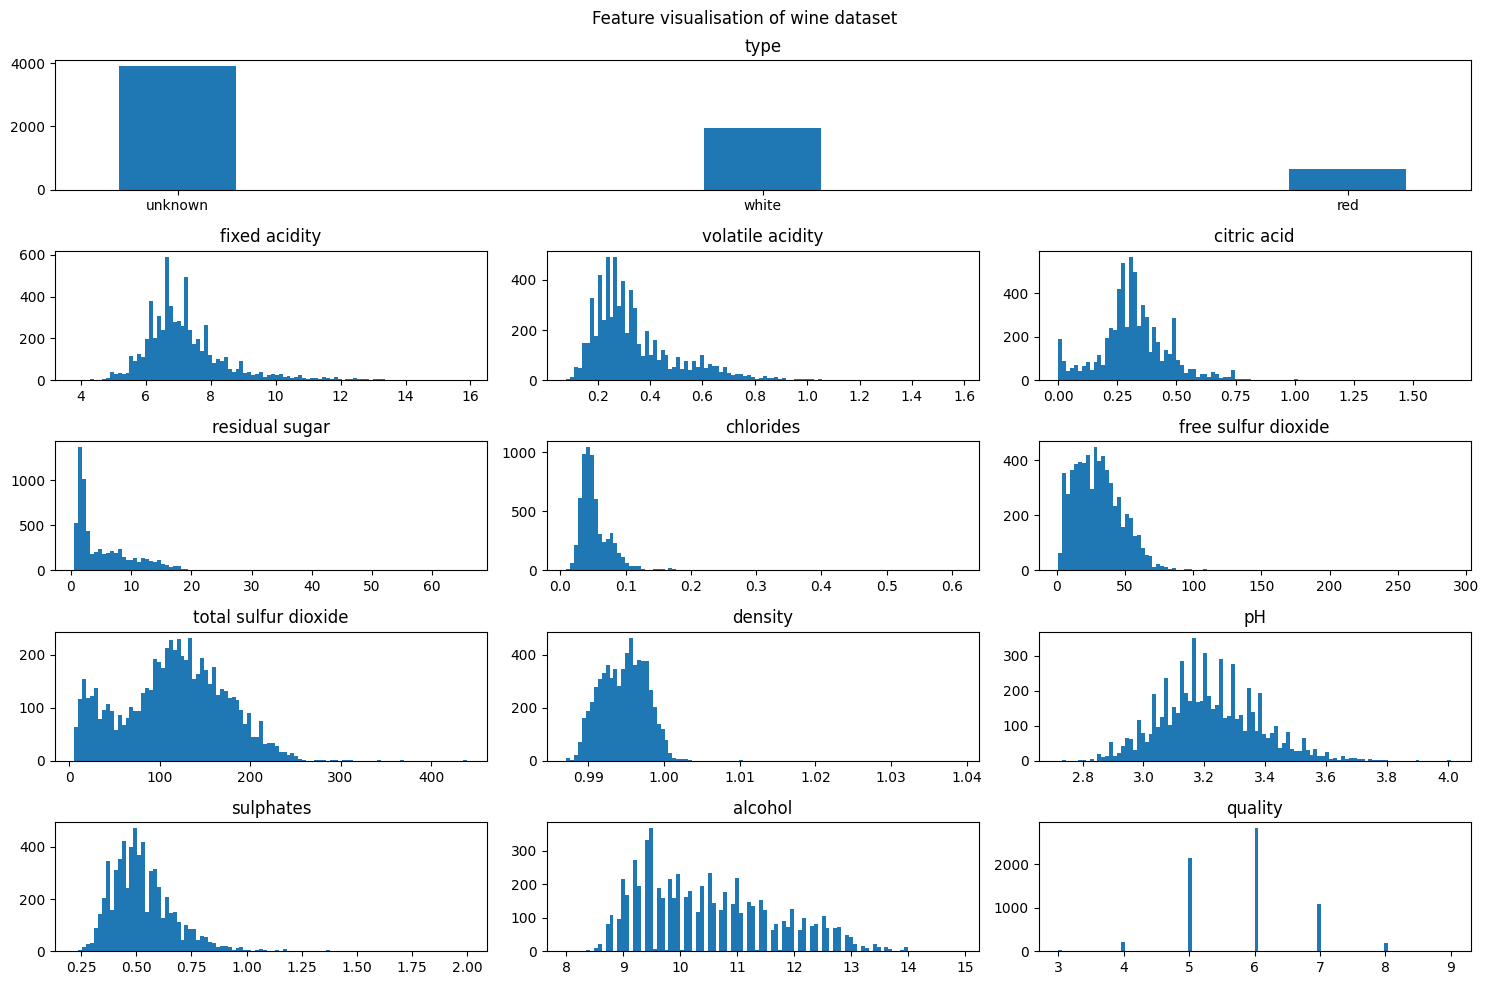

In [177]:
plt.figure(figsize=(15, 10))
for index, col in enumerate(wine.columns):
  if col == 'type':
    plt.subplot(5,1,index+1)
    plt.bar(wine[col].value_counts().index.to_list(), wine[col].value_counts(),
            width=.2)
  else:
    plt.subplot(5,3,index+3)
    plt.hist(wine[col], bins=100)
  plt.title(col)
plt.suptitle('Feature visualisation of wine dataset')
plt.tight_layout()
plt.show()

## Q2 - Target encoding and train/test dataset creation

In [178]:
target_dict = {'unknown': 0,
               'white'  : 1,
               'red'    : 2}

X = np.array(wine.drop(columns='type'))
Y = np.array(wine['type'])
Y = np.array([target_dict[y] for y in Y])

X.shape, Y.shape

((6497, 12), (6497,))

## Q3 - Separate unknown from known targets

In [179]:
mask = wine['type'] != 'unknown'
# -- VERIFY
# print(mask[0][:10])

# print(wine['type'][:15])
x_known, y_known = X[mask], Y[mask]
x_unknown = X[~mask]

## Q4 - Split dataset to stratified train and test

In [180]:
test_size = .3
seed = 42
x_train, x_test, y_train, y_test = train_test_split(x_known, y_known,
                                                    test_size=test_size,
                                                    random_state=seed,
                                                    stratify=y_known)

## Q5 - Train a Random Forest Classifier; evaluate

In [181]:
rf = RandomForestClassifier(random_state=seed)
rf.fit(x_train, y_train)
y_preds = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_preds)
precision, recall, f1_score, support = precision_recall_fscore_support(y_test,
                                                                       y_preds,)

print(f'Random Forest Classifier results')
print(f'  Overall accuracy: {accuracy:.2f}')
print(f'  As per white wines')
print(f'    Precision     : {precision[0]:.2f}')
print(f'    Recall        : {recall[0]:.2f}')
print(f'    F1-score      : {f1_score[0]:.2f}')
print(f'  As per red wines')
print(f'    Precision     : {precision[1]:.2f}')
print(f'    Recall        : {recall[1]:.2f}')
print(f'    F1-score      : {f1_score[1]:.2f}')

Random Forest Classifier results
  Overall accuracy: 1.00
  As per white wines
    Precision     : 1.00
    Recall        : 1.00
    F1-score      : 1.00
  As per red wines
    Precision     : 0.99
    Recall        : 1.00
    F1-score      : 1.00


### Accuracy or F1-score?
While the accuracy is the overall correctness of a model's predictions, the f1-score is a more nuanced evaluation of the model's behavior in its predictive ability. It is the harmonic mean of the Precision (how good the model is at picking the right things, without misclassifying negative instances as positive) and the Recall (how well the model can correctly identify the positive instances out of all the existing ones).

Since our dataset is inherently unbalanced (much fewer 'red' wines than 'white' ones), an F1-score might be more descriptive of a classifier's performance.

## Q6 - Retraining a parameterized Random Forest Classifier for unbalanced data

In [182]:
rf = RandomForestClassifier(random_state=seed, class_weight='balanced')
rf.fit(x_train, y_train)
y_preds = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_preds)
precision, recall, f1_score, support = precision_recall_fscore_support(y_test,
                                                                       y_preds,)

print(f'Random Forest Classifier results')
print(f'  Overall accuracy: {accuracy:.2f}')
print(f'  As per white wines')
print(f'    Precision     : {precision[0]:.2f}')
print(f'    Recall        : {recall[0]:.2f}')
print(f'    F1-score      : {f1_score[0]:.2f}')
print(f'  As per red wines')
print(f'    Precision     : {precision[1]:.2f}')
print(f'    Recall        : {recall[1]:.2f}')
print(f'    F1-score      : {f1_score[1]:.2f}')

Random Forest Classifier results
  Overall accuracy: 0.99
  As per white wines
    Precision     : 0.99
    Recall        : 1.00
    F1-score      : 1.00
  As per red wines
    Precision     : 0.99
    Recall        : 0.98
    F1-score      : 0.99


### What does `class_weight='balanced'` do?
The 'balanced' mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as `n_samples / (n_classes * np.bincount(y))`.

This allows the model to assign a priori a bigger weight on under-represented classes, and a smaller weight on over-represented classes, thus taking into account the per-class distribution of y values.

## Q7 - Predict probability of unknown values

In [183]:
y_unknown_proba = rf.predict_proba(x_unknown)

## Q8 - Assign labels based on predicted probability

In [184]:
threshold = .65
y_unknown_pred = rf.classes_[y_unknown_proba.argmax(axis=1)]
# get the probability that was used to assign a temporary label
y_conf = np.max(y_unknown_proba, axis=1)

# mask based on threshold
conf_mask = y_conf > threshold

## Q9 - Concatenate results to dataset

In [185]:
x_labeled = x_known.copy()
y_labeled = y_known.copy()

if not np.any(conf_mask):
  print('All unknown entries have been classified!')
else:
  x_labeled = np.vstack([x_labeled, x_unknown[conf_mask]])
  y_labeled = np.concatenate([y_labeled, y_unknown_pred[conf_mask]])

  # upadte x_unknown
  x_unknown = x_unknown[~conf_mask]

## Q10 - Repeat until nothing remains in x_unknown

In [186]:
i = 1 # already ran once above
while len(x_unknown) > 0:
  y_unknown_proba = rf.predict_proba(x_unknown)
  y_unknown_pred = rf.classes_[y_unknown_proba.argmax(axis=1)]
  # get the probability that was used to assign a temporary label
  y_conf = np.max(y_unknown_proba, axis=1)

  # mask based on threshold
  conf_mask = y_conf > threshold
  x_labeled = x_known.copy()
  y_labeled = y_known.copy()

  if not np.any(conf_mask):
    print(f'All unknown entries have been classified! Took {i} runs.')
    break

  x_labeled = np.vstack([x_labeled, x_unknown[conf_mask]])
  y_labeled = np.concatenate([y_labeled, y_unknown_pred[conf_mask]])

  # upadte x_unknown
  x_unknown = x_unknown[~conf_mask]
  i += 1

All unknown entries have been classified! Took 1 runs.


# Part 2

## Load dataset
Load the `wine-full.csv` dataset (no missing values).

In [187]:
wine_full = 'https://raw.githubusercontent.com/lazarosgogos/ML-exercises/refs/heads/main/wine-full.csv'
df = pd.read_csv(wine_full)
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


<BarContainer object of 7 artists>

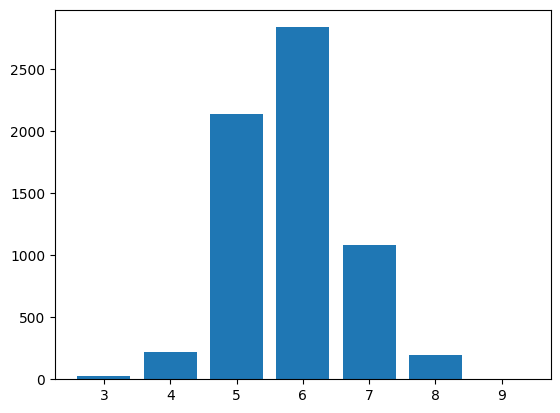

In [188]:
plt.figure(2)
plt.bar(df['quality'].value_counts().index.to_list(), df['quality'].value_counts())

### Is the quality balanced across samples?
As illustrated in the bar plot above, the quality counts follow a gaussian distribution, since most of the quality values are concentrated around 6. This means that most samples will have a quality value of 6,5 or 7. Thus, this is an imbalanced dataset, in terms of quality.

## Q2 - Is red wine better than white wine?

type
red      5.636023
white    5.877909
Name: quality, dtype: float64


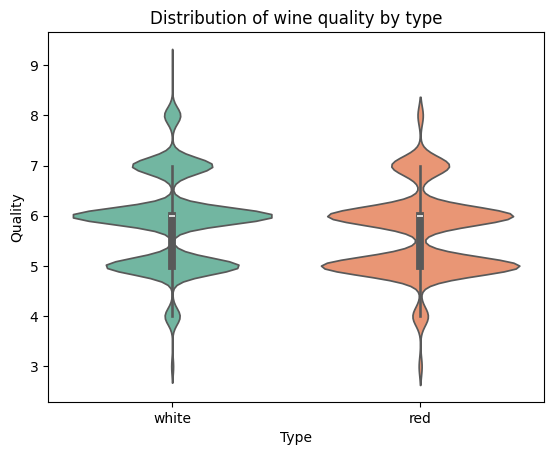

In [189]:
type_df = df['type']
quality_df = df['quality']
mean_quality = df.groupby('type')['quality'].mean()
print(mean_quality)

sns.violinplot(data=df[['type', 'quality']], x='type', y='quality',
               palette='Set2', inner='box', hue='type')
plt.title('Distribution of wine quality by type')
plt.xlabel('Type')
plt.ylabel('Quality')
plt.show();

As illustrated in the violin plot above, the red wine samples have a mean quality of 5.64, but most samples either have a quality of 5 or 6, with none more than 8.

The white wine samples, while they have a slightly higher mean quality (5.88), meaning they also have more wine samples with a quality > 6.

This makes white wines be of slightly better quality than red wines.

## Q3 - Is sweet wine ranked higher than dry wine?

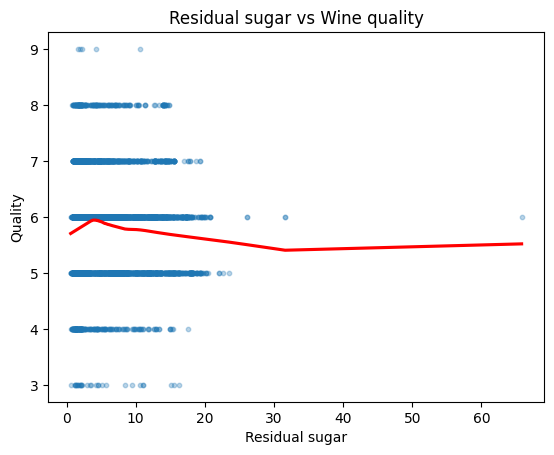

Residual sugar's correlation with quality is -0.04<0, meaning that the sweeter the wine, the lower the quality, as illustrated in the plot as well.


In [190]:
sns.regplot(data=df, x='residual sugar', y='quality',
           lowess=True, scatter_kws={'alpha':0.3, 's':10},
            line_kws={'color':'red'})
plt.xlabel('Residual sugar')
plt.ylabel('Quality')
plt.title('Residual sugar vs Wine quality')
plt.show();
corr_value = df['residual sugar'].corr(df['quality'])
print(f'Residual sugar\'s correlation with quality is {corr_value:.2f}<0, \
meaning that the sweeter the wine, the lower the quality, as illustrated \
in the plot as well.')

## Q4 - Creating a dataset for evaluation

In [191]:
df = df.dropna() # cleanup before feeding to model
X, Y = df.drop(columns=['quality']), df['quality']
X['type'] = X['type'].map({'white':0, 'red':1})

X, Y = np.array(X), np.array(Y)
test_size = .1
seed = 0
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=test_size,
                                                    random_state=seed)
df.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


## Q5 - Create a DecisionTreeRegressor model and assess

In [192]:
dtr = DecisionTreeRegressor(random_state=seed)
dtr.fit(x_train, y_train)
y_preds = dtr.predict(x_test)
error = mean_absolute_error(y_test, y_preds) * 100
print(f'Mean absolute error of a Decision Tree Regressor is: {error:.2f}.')

Mean absolute error of a Decision Tree Regressor is: 44.05.


## Q6 - Create 10 models; extract mean and std

In [193]:
seeds = range(0,10)
maes = []
for seed in seeds:
  test_size = .1
  seed = 0
  x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=test_size,
                                                      random_state=seed)
  dtr = DecisionTreeRegressor(random_state=seed)
  dtr.fit(x_train, y_train)
  y_preds = dtr.predict(x_test)
  error = round(mean_absolute_error(y_test, y_preds) * 100, 2)
  maes.append(error)
maes = np.array(maes)
mean = maes.mean()
std = maes.std()
print(f'The mean absolute error is {mean:.2f}%, and the std is {std:.2f}%, over 10 runs')

The mean absolute error is 44.05%, and the std is 0.00%, over 10 runs


Having a mean of MAEs equal to 44.77% and a standard deviation of 0 over 10 runs with 10 different seeds, this means that the Decision Tree Regressor works quite reliably

## Q7 - Use train-val-test sets and fine-tune the model

In [194]:
test_size = .1
val_size = 2/9 # 20% out of the 90% that contains the dataset
seed=0
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=test_size,
                                                    random_state=seed)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                                  test_size=val_size,
                                                  random_state=seed)
# Y.shape, y_train.shape, y_val.shape, y_test.shape
print(f'Train set size percentage: {(y_train.shape[0]/Y.shape[0])*100:.2f}%')
print(f'Val set size percentage  : {(y_val.shape[0]/Y.shape[0])*100:.2f}%')
print(f'Test set size percentage : {(y_test.shape[0]/Y.shape[0])*100:.2f}%')

config = {'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
          'splitter': ['best', 'random'],
          # 'min_samples_split': [2,4,8,16,32,64],
          'max_features': ['sqrt', 'log2'],
          # 'max_depth': [4,8,16],
          'random_state': [seed],
          }
results = []
grid_cols = [*config.keys()]
grid_cols.remove('random_state')
grid_cols.extend(['train_mae', 'val_mae'])
grid_df = pd.DataFrame(columns=grid_cols)
for criterion in config['criterion']:
  for splitter in config['splitter']:
    for max_features in config['max_features']:
      for random_state in config['random_state']:
      # for min_samples_leaf in config['min_samples_leaf']:
        # for max_depth in config['max_depth']:
      #     for ccp_alpha in config['ccp_alpha']:
            tree = DecisionTreeRegressor(criterion=criterion,
                                         splitter=splitter,
                                          # max_depth=max_depth,
                                          # min_samples_split=min_samples_split,
                                          # min_samples_leaf=min_samples_leaf,
                                          max_features=max_features,
                                          # ccp_alpha=ccp_alpha
                                          random_state=random_state,
                                         )
            tree.fit(x_train, y_train)
            y_pred_train = tree.predict(x_train)
            y_pred_val = tree.predict(x_val)
            tree_mae_train = mean_absolute_error(y_train, y_pred_train)
            tree_mae_val = mean_absolute_error(y_val, y_pred_val)
            results.append((criterion, splitter, max_features,
                            tree_mae_train, tree_mae_val))

grid_df = pd.DataFrame(results, columns=grid_cols)
grid_df

Train set size percentage: 69.98%
Val set size percentage  : 20.01%
Test set size percentage : 10.01%


,criterion,splitter,max_features,train_mae,val_mae
0,squared_error,best,sqrt,0.0,0.522815
1,squared_error,best,log2,0.0,0.522815
2,squared_error,random,sqrt,0.0,0.502707
3,squared_error,random,log2,0.0,0.502707
4,friedman_mse,best,sqrt,0.0,0.523589
5,friedman_mse,best,log2,0.0,0.523589
6,friedman_mse,random,sqrt,0.0,0.501933
7,friedman_mse,random,log2,0.0,0.501933
8,absolute_error,best,sqrt,0.0,0.529002
9,absolute_error,best,log2,0.0,0.529002


One thing to note in the dataframe above is how the train mean absolute error is 0, meaning all models have fit the data perfectly, while the validation mean absolute error is in the range [0.50-0.56].

## Q8 - Training or validation set for hyper-parameter tuning?

The validation set is more appropriate for tuning a model's hyper-parameters, since the model is not trained on the validation set; it is only evaluated on it to determine its performance and alter hyper-parameters as needed.

## Q9 - Use Grid Search with Cross Validation

In [195]:
grid_cv = GridSearchCV(DecisionTreeRegressor(), param_grid=config, n_jobs=-1,
                       return_train_score=True, scoring='neg_mean_absolute_error',
                       cv=10)
grid_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_features': ['sqrt', 'log2'], 'random_state': [0],
                         'splitter': ['best', 'random']},
             return_train_score=True, scoring='neg_mean_absolute_error')

## Q10 - Assess best estimator

In [196]:
y_pred_test = grid_cv.best_estimator_.predict(x_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
print(f'The mean absolute error on the test set is: {mae_test*100:.2f}.')

The mean absolute error on the test set is: 47.45.


### What is the best way of training a Decision Tree Regressor, out of the above 3?
It appears that the smallest mean absolute error is achieved with the first method (Q6), meaning that out of the 3 way of training models, the best one is by creating 10 models and getting a mean out of them (like RandomForest would).

## Q11 - Plot the best tree

In [238]:
config['max_depth'] = [5]
grid_cv = GridSearchCV(DecisionTreeRegressor(), param_grid=config, n_jobs=-1,
                       return_train_score=True, scoring='neg_mean_absolute_error',
                       cv=10)
grid_cv.fit(x_train, y_train)
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)
plt.figure(3, figsize=(60, 20), dpi=300)
X_df, Y_df = df.drop(columns=['quality']), df['quality']
feature_names = list(X_df.columns)
class_names = Y_df.unique()
plot_tree(grid_cv.best_estimator_, feature_names=X_df.columns,
          class_names=class_names, fontsize=14);

The root node splits the tree in two parts; the left half contains the samples with a residual sugar <= 17.78, and the right half contains the rest.

A wine sample will have the highest possible score if it has residual sugar lower than 17.78, citric acid more than 0.24 and less than 0.38, alchohol more than 9.77, and fixed acidity less than 4.6.

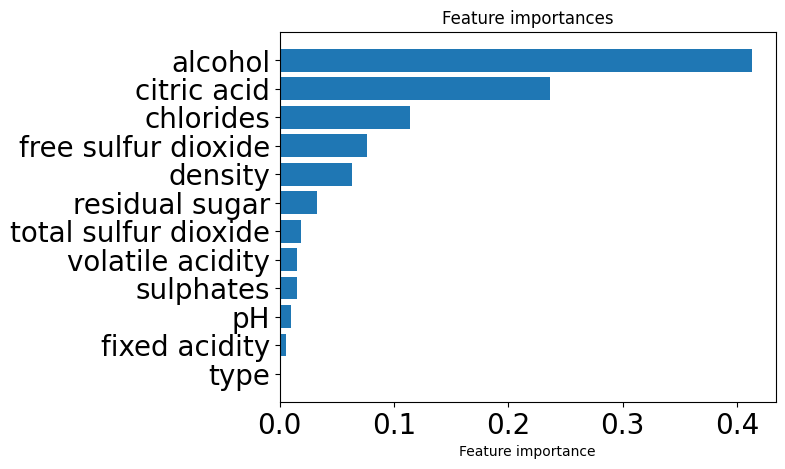

In [248]:
best = grid_cv.best_estimator_
importances = best.feature_importances_
feature_names = list(X_df.columns)

indices = np.argsort(importances)

plt.barh(np.array(feature_names)[indices], importances[indices], )
plt.xlabel('Feature importance')
plt.title('Feature importances')
plt.show();